<a href="https://colab.research.google.com/github/Hu-Yuting/GEOG5990M/blob/main/GEOG5990M_Final_Project_template_201929800.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GEOG5990M Final Assignment

(The cover sheet has been adapted from the word doc. to support use with .ipynb files - please complete all the requested info.)
###  COURSEWORK COVERSHEET
- Student ID number: 201929800
- Module code: GEOG5990M
- Module title: Programming for Geographical Information Analysis: Core Skills
- Assignment title: Spatial data science report
- Marker: Francesca Pontin
- Declared word count: 1465

#### Use of Generative Artificial Intelligence (Gen AI) in this assessment – delete one statement as appropriate
- I have used Gen AI only for the specific purposes outlined in my acknowledgements


By submitting the work in this notebook you confirm your compliance with the University’s definition of Academic Integrity as: “a commitment to good study practices and shared values which ensures that my work is a true expression of my own understanding and ideas, giving credit to others where their work contributes to mine”. Double-check that your referencing and use of quotations is consistent with this commitment.

You also confirm that your declared word count accurately reflects the number of words in your submission, excluding the overall title, Gen AI use acknowledgement, bibliography/reference list, text/numbers in tables and figures (although table and figure captions are included in the word count).

## Introduction

This report focuses on the spatial distribution of no-car households in Leeds, and the relationship between the percentage of no-car households and the percentage of public transportation usage. Transport accessibility is closely related to the daily life of residents. For households with no cars or vans, public transportation is an important way for commuting. If both of the percentages are very high in some areas, it indicates that these areas have a greater need for public transportation. Once the public transportation services become insufficient, the frequency decreases or the accessibility becomes poor, it will affect the daily life of residents (1). Therefore, identifying the spatial distribution of no-car households in the city and analyzing the relationship between this and the public transportation usage can help understand the differences in transportation demands among different areas within the city. It can also provide a reference for reasonable allocation of transportation resources, which is of significant public good.

<a href="https://doi.org/10.3390/socsci8020058">[1] </a> Berg, J. and Ihlström, J., 2019. The importance of public transport for mobility and everyday activities among rural residents. Social Sciences, 8(2), p.58. Available from: https://doi.org/10.3390/socsci8020058.

## Data and source

Three public datasets were downloaded. Two attribute datasets are from Nomis' Census data (https://www.nomisweb.co.uk).

One is the "Car or van availability" dataset (https://www.nomisweb.co.uk/datasets/c2021ts045), which is used for the number and percentage of households with no cars or vans.

The other is the " Method used to travel to work" dataset (https://www.nomisweb.co.uk/datasets/c2021ts061), which is used for the number and percentage of people commuting using "bus, minibus or coach".

The spatial boundary data is the 2021 MSOA boundary file downloded from the ONS Geoportal (https://geoportal.statistics.gov.uk).

The geographical units of the three datasets are all Middle Layer Super Output Areas (MSOA). The units can reflect the spatial differences within the city without making the map too fragmented, and using the same units makes it convenient for subsequent data join. These data are also in line with the research questions: "Car or van availability" data reflects the vehicle ownership status of residents, "Method used to travel to work" data reflects the public transportation usage, and the boundary data enables the attribute data can be expressed spatially.


## Data exploration

Read in required packages and two attribute data from GitHub. Since the data downloaded from Nomis have some descriptive information at the beginning and end, which are not the actual data. So select the truly useful data during the reading process. Ater reading in the data, use some basic check code to view the first few rows of the data, column names, data types, and the missing data, helping us understand the data structure and check whether there are any errors in the imported data.


In [ ]:
# read in required packages
# Import pandas for reading, exploring and cleaning data
import pandas as pd

# Import geopandas for spatial data handling
import geopandas as gpd

# Import matplotlib for plotting
import matplotlib.pyplot as plt

# Import seaborn for visualisation
import seaborn as sns

In [ ]:
# Read in the data from GitHub
# The following prompt was used in ChatGPT-5.4 Thinking to read in the data from specified rows:
# "When reading in a CSV file in colab, I want to obtain data from specified rows. How should I write the code?"
# The repsonse generated was used to help generate the code below.
no_car =pd.read_csv('https://github.com/Hu-Yuting/GEOG5990M/raw/refs/heads/main/Leeds_MSOA_no_car_households.csv', skiprows=6, nrows=108)
bus_use =pd.read_csv('https://github.com/Hu-Yuting/GEOG5990M/raw/refs/heads/main/Leeds_MSOA_bus_use.csv', skiprows=6, nrows=108)

In [ ]:
# Look at the first 5 rows of the dataframe
no_car.head()
bus_use.head()

# Check the column names
no_car.columns
bus_use.columns

# Check the data types and missing data
no_car.info()
no_car.isnull().sum()
bus_use.info()
bus_use.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108 entries, 0 to 107
Data columns (total 6 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   2021 super output area - middle layer  107 non-null    object 
 1   mnemonic                               107 non-null    object 
 2   Total: All households                  107 non-null    float64
 3   %                                      107 non-null    float64
 4   No cars or vans in household           107 non-null    float64
 5   %.1                                    107 non-null    float64
dtypes: float64(4), object(2)
memory usage: 5.2+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108 entries, 0 to 107
Data columns (total 6 columns):
 #   Column                                                                                      Non-Null Count  Dtype  
---  ------                                                                

,0
2021 super output area - middle layer,1
mnemonic,1
Total: All usual residents aged 16 years and over in employment the week before the census,1
%,1
"Bus, minibus or coach",1
%.1,1


## Data cleaning

The results show that there is an empty record in each of the two data. Therefore, use .drop() to delete the empty row, remove the invalid values and reset the index, making the data look tidy (2). Then rename the column names. The original column names were quite long and contained a lot of descriptive text, which was not helpful for subsequent code writing and understanding. Change them to more clear names. This not only makes the code easier to read, but also enables a clearer expression of the variable meanings during subsequent merge and plotting. Next retain the variables that are necessary for the analysis. In this way, it can reduce the influence of irrelevant variables and also avoid generating too many columns during the merge (3). After cleaning and organizing the data, recheck them to ensure the accuracy.

In [ ]:
# Remove the empty first row and reset the index
# The following prompt was used in ChatGPT-5.4 Thinking to reset the index:
# "After deleting the 0th row, reset the index of the dataframe to start from 0 and do not retain the previous numbers. How should I write the code?"
# The repsonse generated was used to help generate the code below.
no_car = no_car.drop([0], axis=0).reset_index(drop=True)
bus_use = bus_use.drop([0], axis=0).reset_index(drop=True)

# Rename the columns to make them easier to read
# The following prompt was used in ChatGPT-5.4 Thinking to rename the columns:
# "I want to rename the columns of a CSV file. How should I write the code?"
# The repsonse generated was used to help generate the code below.
no_car.columns = ['msoa_name', 'msoa_code', 'total_households', 'total_pct', 'no_car_households', 'no_car_pct']
bus_use.columns = ['msoa_name', 'msoa_code', 'total_residents', 'total_pct', 'bus_users', 'bus_pct']

# Select variables needed for analysis
no_car = no_car[['msoa_name', 'msoa_code', 'no_car_households', 'no_car_pct']]
bus_use = bus_use[['msoa_code', 'bus_users', 'bus_pct']]

# Check the renamed and reduced dataset
no_car.head()
bus_use.head()

# Recheck the column names
no_car.columns
bus_use.columns

# Recheck for the data type and missing data
no_car.info()
no_car.isnull().sum()
bus_use.info()
bus_use.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107 entries, 0 to 106
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   msoa_name          107 non-null    object 
 1   msoa_code          107 non-null    object 
 2   no_car_households  107 non-null    float64
 3   no_car_pct         107 non-null    float64
dtypes: float64(2), object(2)
memory usage: 3.5+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107 entries, 0 to 106
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   msoa_code  107 non-null    object 
 1   bus_users  107 non-null    float64
 2   bus_pct    107 non-null    float64
dtypes: float64(2), object(1)
memory usage: 2.6+ KB


,0
msoa_code,0
bus_users,0
bus_pct,0


<a href="https://doi.org/10.3390/data6020011">[2] </a> Alshdaifat, E., Alshdaifat, D., Alsarhan, A., Hussein, F. and El-Salhi, S.M.F.S., 2021. The effect of preprocessing techniques, applied to numeric features, on classification algorithms’ performance. Data, 6(2), pp.11-23. Available from: https://doi.org/10.3390/data6020011.

<a href="https://doi.org/10.1145/3592616">[3] </a> Priestley, M., O’Donnell, F. and Simperl, E., 2023. A survey of data quality requirements that matter in ML development pipelines. ACM Journal of Data and Information Quality, 15(2), Article 11, pp.1–39. Available from: https://doi.org/10.1145/3592616.

## Visualisations to assist checking data

Conducts simple visualisations to assist checking data. Draw the histograms of 'no_car_pct' and 'bus_pct' to view the distribution. Compared with descriptive statistics, histograms can more intuitively show the overall distribution of the variables and can help determine whether there are any obvious outliers or extreme values in the variables (4). From the descriptive statistics and histograms, 'no_car_pct' shows significant differences in Leeds. The 'bus_pct' also shows significant differences and most areas are concentrated in relatively low to moderate levels, indicating that the public transportation usage is not evenly distributed in Leeds.

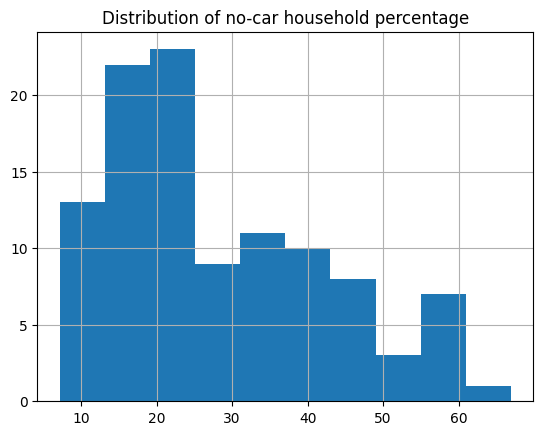

In [ ]:
# Use visualisation to check the distribution of no-car household percentage
no_car['no_car_pct'].hist()
plt.title('Distribution of no-car household percentage')
plt.show()

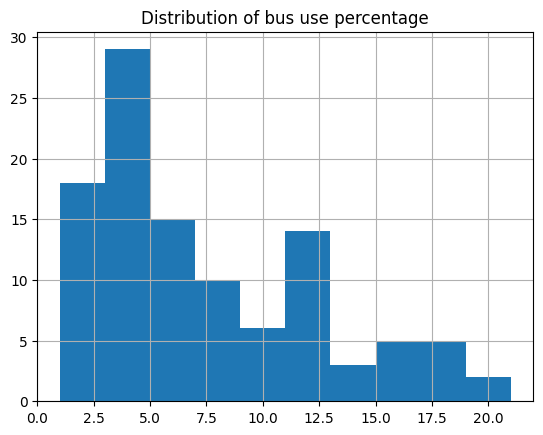

In [ ]:
# Use visualisation to check the distribution of bus-use percentage
bus_use['bus_pct'].hist()
plt.title('Distribution of bus use percentage')
plt.show()

<a href="https://doi.org/10.1145/3448016.3457330">[4] </a> Peng, J., Wu, W., Lockhart, B., Bian, S., Yan, J.N., Xu, L., Chi, Z., Rzeszotarski, J.M. and Wang, J., 2021. DataPrep.EDA: task-centric exploratory data analysis for statistical modeling in Python. Proceedings of the 2021 International Conference on Management of Data, pp.2271–2280. Available from: https://doi.org/10.1145/3448016.3457330.

## Merge and join data
Merge the two attribute data into a main attribute table through the MSOA code and read in the MSOA boundary data from Google Drive. Since the boundary file is for the whole country, but this project only focuses on Leeds, so select the boundaries of Leeds from the national boundaries based on the MSOA code. Finally, join the boundary data with the main attribute table based on the MSOA code to obtain the final GeoDataFrame.

In [ ]:
# Merge the two attribute tables using the common MSOA code
merge_no_car_bus_use = pd.merge(no_car, bus_use, on='msoa_code')

# Ckeck the merged attribute table
merge_no_car_bus_use.head()

# Check the number of rows and columns of the merged table
merge_no_car_bus_use.shape

# Check for missing data
merge_no_car_bus_use.isnull().sum()

,0
msoa_name,0
msoa_code,0
no_car_households,0
no_car_pct,0
bus_users,0
bus_pct,0


In [ ]:
# Mount Google Drive to access the large boundary file
from google.colab import drive
drive.mount('/content/drive')

# Read in the national MSOA boundary file from Google Drive
msoa_all = gpd.read_file('/content/drive/MyDrive/MSOA_2021_Boundaries.geojson')

# Look at the first 5 rows of the dataframe
msoa_all.head()

# Check the column names
msoa_all.columns

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Index(['FID', 'MSOA21CD', 'MSOA21NM', 'MSOA21NMW', 'BNG_E', 'BNG_N', 'LAT',
       'LONG', 'GlobalID', 'geometry'],
      dtype='object')

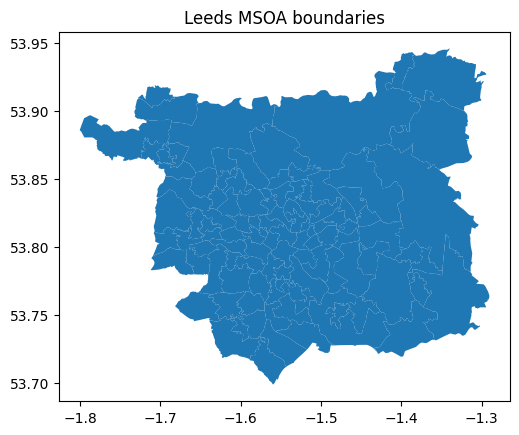

In [ ]:
# Subset the national boundary file to Leeds MSOAs only
leeds_msoa = msoa_all.loc[msoa_all['MSOA21CD'].isin(merge_no_car_bus_use['msoa_code']), :]

# Check the first 5 rows of the Leeds boundary subset
leeds_msoa.head()

# Check the number of rows and columns in the Leeds boundary subset
leeds_msoa.shape

# Plot the Leeds boundary subset
leeds_msoa.plot()
plt.title('Leeds MSOA boundaries')
plt.show()

# Check the CRS of the spatial data
leeds_msoa.crs

# Save the Leeds boundary file as a .geojson
leeds_msoa.to_file('/content/drive/MyDrive/leeds_msoa_boundaries.geojson', driver='GeoJSON')

In [ ]:
# Join the merged attribute data to the Leeds boundary
leeds_msoa = pd.merge(leeds_msoa, merge_no_car_bus_use, left_on='MSOA21CD', right_on='msoa_code', how='left')

# Check the first 5 rows of the joined dataframe
leeds_msoa.head()

# Check for missing data
leeds_msoa.isnull().sum()

# Get some basic summary statisitcs
leeds_msoa.describe()

,FID,BNG_E,BNG_N,LAT,LONG,no_car_households,no_car_pct,bus_users,bus_pct
count,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000
mean,2444.897196,429703.728972,434963.121495,53.810098,-1.550412,916.682243,28.260748,253.747664,7.547664
std,825.926740,5887.276022,4854.270349,0.043663,0.089374,557.735272,14.667560,155.092613,5.005758
min,2232.000000,416431.000000,424520.000000,53.716320,-1.751550,217.000000,7.200000,38.000000,1.000000
25%,2258.500000,425473.500000,431765.000000,53.781520,-1.614885,538.500000,16.850000,126.500000,3.700000
50%,2285.000000,429641.000000,434846.000000,53.809370,-1.550930,755.000000,23.500000,206.000000,5.500000
75%,2311.500000,433323.500000,437893.500000,53.836490,-1.495130,1135.000000,39.200000,376.000000,11.500000
max,6623.000000,443490.000000,447994.000000,53.926600,-1.341640,2786.000000,66.900000,628.000000,21.000000


## Exploratory analysis

Conduct exploratory analysis before the formal mapping to determine whether the variables are suitable for further analysis (5). This project uses a bivariate association analysis model. Choosing this model because the research question mainly focuses on whether there is a relationship between two variables. For such questions, bivariate association analysis can directly show the answer. This method is simpler and easier to explain. It can directly show the relationship between variables without relying on complex models (6).

The initial choropleth map shows a clear spatial pattern. Areas with a high value of 'no_car_pct' are mainly concentrated in the center of Leeds, while the outer areas have low values, presenting a "center-outer" distribution pattern. The initial scatterplot shows a positive trend between 'bus_pct' and 'no_car_pct'. Areas with a high value of 'no_car_pct' also have a high value of 'bus_pct'. The results show that both of the variables have obvious spatial differences, and thus are suitable for further analysis.


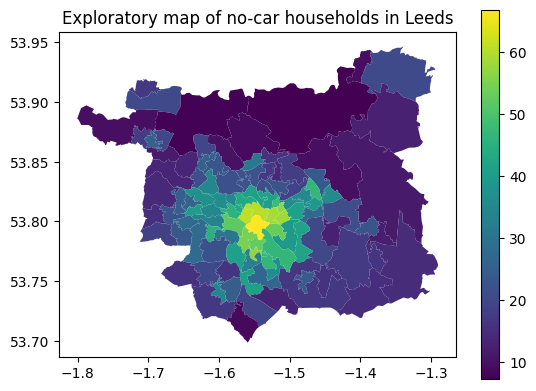

In [ ]:
# Create a simple choropleth map to explore the spatial distribution of no-car households
leeds_msoa.plot(column='no_car_pct', legend=True)
plt.title('Exploratory map of no-car households in Leeds')
plt.show()

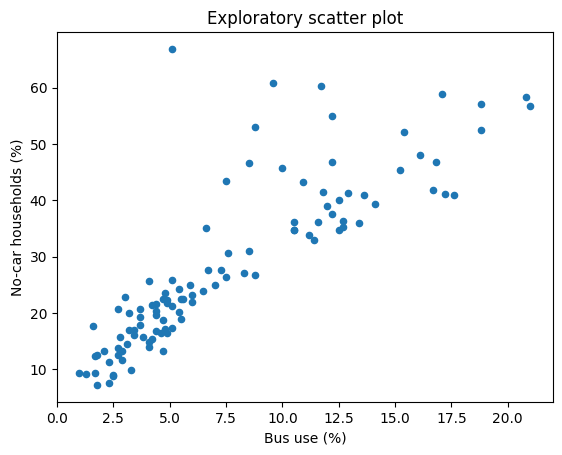

In [ ]:
# Create a simple scatterplot to explore the relationship between bus use and no-car households
leeds_msoa.plot.scatter(x='bus_pct', y='no_car_pct')
plt.title('Exploratory scatter plot')
plt.xlabel('Bus use (%)')
plt.ylabel('No-car households (%)')
plt.show()

<a href="https://doi.org/10.2307/30141948">[5] </a> Shelly, M.A., 1996. Exploratory data analysis: data visualization or torture? Infection Control and Hospital Epidemiology, 17(9), pp.605–612. Available from: https://doi.org/10.2307/30141948.

<a href="https://doi.org/10.1007/s101090100064">[6] </a> Lee, S.-I., 2001. Developing a bivariate spatial association measure: An integration of Pearson’s r and Moran’s I. Journal of Geographical Systems, 3(4), pp.369–385. Available from: https://doi.org/10.1007/s101090100064.

Data Visualisation
- Don't forget to present your final two data visualisation (one spatial and one non-spatial) and the justifications about the decisions you made whilst preparing and visualising the data.

## Spatial visualisation

Use a choropleth map to show the percentage of households with no cars or vans in Leeds MSOAs. The choropleth map is suitable for presenting spatial differences, as it enables readers to see intuitively where no-car households are more concentrated (7). When mapping, I add a title and a legend to help readers understand the content of the map. Removing the axes to make the map look cleaner. Using continuous color bands to make the spatial distribution of high and low values more obvious.

The intended audience is readers interested in urban transportation, public services and social equity, as well as local planners and policy makers. The core insight is that no-car households are not evenly distributed in Leeds but are clearly concentrated in the central area, indicating an imbalance in transportation demand in the city, which is useful for discussing the accessibility of public transportation and the transportation equity (8).


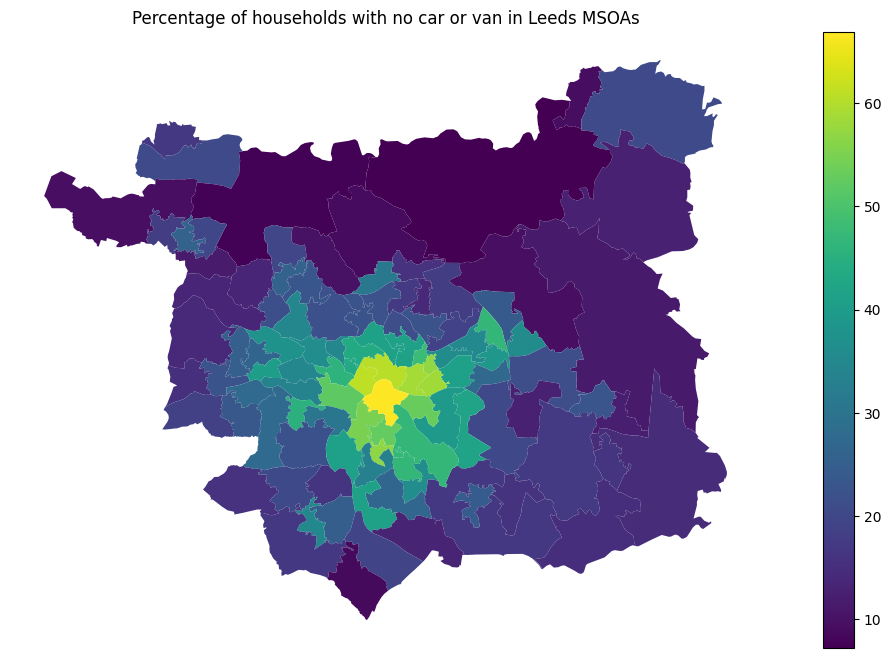

In [ ]:
# Spatial visualisation
# Define plot size
f,ax = plt.subplots(1, figsize=(16,8))

# Create a choropleth map
leeds_msoa.plot(ax=ax, column='no_car_pct', legend=True, cmap='viridis')

# Add a title
ax.set_title('Percentage of households with no car or van in Leeds MSOAs')

# Remove axes to make the map cleaner
ax.set_axis_off()

# Display the figure
plt.show()

<a href="https://doi.org/10.1016/j.compenvurbsys.2016.04.003">[7] </a> Wei, R., Tong, D. and Phillips, J.M., 2017. An integrated classification scheme for mapping estimates and errors of estimation from the American Community Survey. Computers, Environment and Urban Systems, 63, pp.95–103. Available from: https://doi.org/10.1016/j.compenvurbsys.2016.04.003.

<a href="https://doi.org/10.1080/1523908X.2013.858592">[8] </a> Mattioli, G., 2014. Where sustainable transport and social exclusion meet: Households without cars and car dependence in Great Britain. Journal of Environmental Policy & Planning, 16(3), pp.379–400. Available from: https://doi.org/10.1080/1523908X.2013.858592.

## Non-spatial visualisation

Use a scatterplot to show the relationship between the percentage of the public transportation usage and the percentage of no-car households. Scatterplots do not emphasize location but rather the correlation, and can directly show the overall trend between two variables (9). Similarly, I add the title and the axis labels when mapping, using more straightforward expressions to enhance the readability.

The intended audience is also the general readers, local policy makers, and readers interested in the spatial structure of Leeds. The core insight is that areas with a high percentage of no-car households usually have a high percentage of public transport usage. This indicates that there are some communities within Leeds rely more on public transportation. In traffic planning, attention should be paid to these communities and the transportation resources should be reasonably allocated.


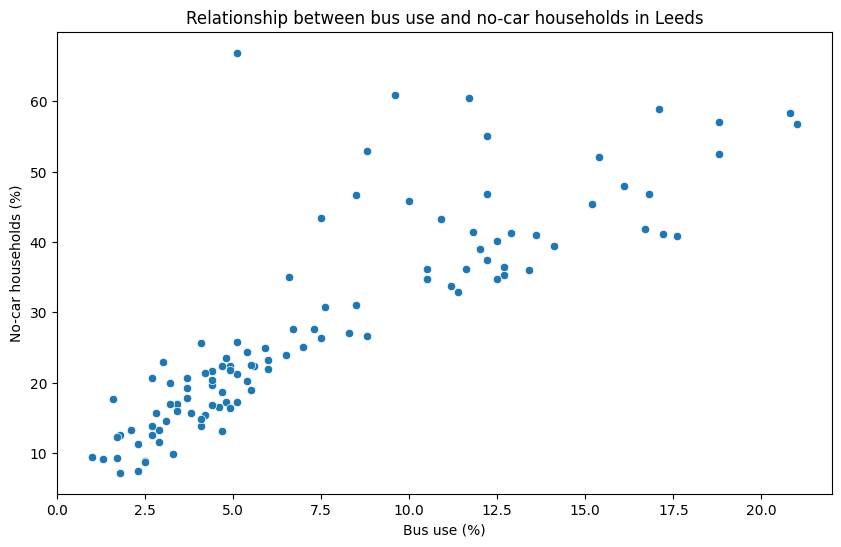

In [ ]:
# Non-spatial visualisation
# Define plot size
plt.figure(figsize=(10,6))

# Create a scatterplot showing the relationship between bus use and no-car households in Leeds
sns.scatterplot(x='bus_pct', y='no_car_pct', data=leeds_msoa)

# Add a title
plt.title('Relationship between bus use and no-car households in Leeds')

# Add axis labels
plt.xlabel('Bus use (%)')
plt.ylabel('No-car households (%)')

# Display the figure
plt.show()

<a href="https://doi.org/10.1016/j.pmrj.2016.10.018">[9] </a> Sainani, K.L., 2016. The value of scatter plots. PM&R, 8(12), pp.1213–1217. Available from: https://doi.org/10.1016/j.pmrj.2016.10.018.

## Conclusion

This project analyzes the spatial distribution of no-car households in Leeds and the relationship between it and public transportation usage. The results indicate that no-car households in Leeds show an uneven distribution, with a high percentage in the central areas and a low percentage in the outer areas. Additionally, there is a clear positive correlation between the percentage of public transportation usage and the percentage of no-car households. The areas with a high percentage of no-car households usually rely more on public transportation.

This result is of significant public good. It indicates that different areas within Leeds have different degrees of reliance on public transportation. Some areas rely more on public transportation for daily commuting. Therefore, when allocating transportation resources, these areas should be fully considered to provide more stable, accessible and equitable public transportation services. Such spatial differences cannot be ignored, as only considering the average level of the city often means ignoring the internal differences, which may lead to the inequality. The result can provide a more detailed reference for allocating transportation resource and planning public service.

This project also has some limitations. Firstly, the analysis only uses two variables, which cannot fully explain all the factors leading to the differences. Secondly, the study area is focus on Leeds, so the results are specific to Leeds and cannot directly applied to other regions. Finally, the project analyze the relationship between variables and should not assume that one variable directly causing the changes in another. If further study is conducted in the future, more variables can be considered, such as other commuting methods, population structure or living conditions, to explain the relationship between no-car households and public transportation usage more comprehensively.


## GenAl Use Acknowledgement

I acknowledge the use of ChatGPT-5.4 Thinking (OpenAl, https://chat.openai.com) for initial brainstorming of assessment brief, AI prompt used: Please help me analyse and summarise the assignment brief.

I acknowledge the use of ChatGPT-5.4 Thinking (OpenAl, https://chat.openai.com) to support development of code to read in the data from specified rows, AI prompt used: When reading in a CSV file in colab, I want to obtain data from specified rows. How should I write the code?

I acknowledge the use of ChatGPT-5.4 Thinking (OpenAl, https://chat.openai.com) to support development of code to reset the index, AI prompt used: After deleting the 0th row, reset the index of the dataframe to start from 0 and do not retain the previous numbers. How should I write the code?

I acknowledge the use of ChatGPT-5.4 Thinking (OpenAl, https://chat.openai.com) to support development of code to rename the columns, AI prompt used: I want to rename the columns of a CSV file. How should I write the code?

I acknowledge the use of ChatGPT-5.4 Thinking (OpenAl, https://chat.openai.com) for grammar and spelling checking, AI prompt used: Please help me check the grammar and spelling.


## References
<p><a href="https://doi.org/10.3390/socsci8020058">[1] </a> Berg, J. and Ihlström, J., 2019. The importance of public transport for mobility and everyday activities among rural residents. Social Sciences, 8(2), p.58. Available from: https://doi.org/10.3390/socsci8020058.</p>

<p><a href="https://doi.org/10.3390/data6020011">[2] </a> Alshdaifat, E., Alshdaifat, D., Alsarhan, A., Hussein, F. and El-Salhi, S.M.F.S., 2021. The effect of preprocessing techniques, applied to numeric features, on classification algorithms’ performance. Data, 6(2), pp.11-23. Available from: https://doi.org/10.3390/data6020011.</p>

<p><a href="https://doi.org/10.1145/3592616">[3] </a> Priestley, M., O’Donnell, F. and Simperl, E., 2023. A survey of data quality requirements that matter in ML development pipelines. ACM Journal of Data and Information Quality, 15(2), Article 11, pp.1–39. Available from: https://doi.org/10.1145/3592616.</p>

<p><a href="https://doi.org/10.1145/3448016.3457330">[4] </a> Peng, J., Wu, W., Lockhart, B., Bian, S., Yan, J.N., Xu, L., Chi, Z., Rzeszotarski, J.M. and Wang, J., 2021. DataPrep.EDA: task-centric exploratory data analysis for statistical modeling in Python. Proceedings of the 2021 International Conference on Management of Data, pp.2271–2280. Available from: https://doi.org/10.1145/3448016.3457330.</p>

<p><a href="https://doi.org/10.2307/30141948">[5] </a> Shelly, M.A., 1996. Exploratory data analysis: data visualization or torture? Infection Control and Hospital Epidemiology, 17(9), pp.605–612. Available from: https://doi.org/10.2307/30141948.</p>

<a href="https://doi.org/10.1007/s101090100064">[6] </a> Lee, S.-I., 2001. Developing a bivariate spatial association measure: An integration of Pearson’s r and Moran’s I. Journal of Geographical Systems, 3(4), pp.369–385. Available from: https://doi.org/10.1007/s101090100064.

<p><a href="https://doi.org/10.1016/j.compenvurbsys.2016.04.003">[7] </a> Wei, R., Tong, D. and Phillips, J.M., 2017. An integrated classification scheme for mapping estimates and errors of estimation from the American Community Survey. Computers, Environment and Urban Systems, 63, pp.95–103. Available from: https://doi.org/10.1016/j.compenvurbsys.2016.04.003.</p>

<p><a href="https://doi.org/10.1080/1523908X.2013.858592">[8] </a> Mattioli, G., 2014. Where sustainable transport and social exclusion meet: Households without cars and car dependence in Great Britain. Journal of Environmental Policy & Planning, 16(3), pp.379–400. Available from: https://doi.org/10.1080/1523908X.2013.858592.</p>

<p><a href="https://doi.org/10.1016/j.pmrj.2016.10.018">[9] </a> Sainani, K.L., 2016. The value of scatter plots. PM&R, 8(12), pp.1213–1217. Available from: https://doi.org/10.1016/j.pmrj.2016.10.018.</p>
